In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold


In [3]:
df = pd.read_csv("ANEMIA_DA.csv", sep = ";")
df['GRADO_SEVERIDAD'] = df['GRADO_SEVERIDAD'].str.upper()
df['ETNIA_AGRUPADA'] = df['ETNIA'].mask(df['ETNIA'].str.upper() != 'MESTIZO', 'INDIGENA')
altitud_media = {
    'PROVINCIA': [
        'MOYOBAMBA', 'BELLAVISTA', 'EL DORADO', 'HUALLAGA', 
        'LAMAS', 'MARISCAL CACERES', 'PICOTA', 'RIOJA', 
        'SAN MARTIN', 'TOCACHE'
    ],
    'ALTITUD_MSNM': [878, 285, 346, 303, 791, 282, 223, 841, 356, 502]
}
df_maestro_alt = pd.DataFrame(altitud_media)
df['PROVINCIA'] = df['PROVINCIA'].str.upper().str.strip()
df['PROVINCIA'] = df['PROVINCIA'].str.replace('Á', 'A').str.replace('É', 'E').str.replace('Í', 'I').str.replace('Ó', 'O').str.replace('Ú', 'U')
df = df.merge(df_maestro_alt, on='PROVINCIA', how='left')

def dias(row):
    edad = row['EDAD_REGISTRO']
    tipo = str(row['TIPO_EDAD']).upper().strip()
    
    if tipo == 'A':    # Años
        return edad
    elif tipo == 'M':  # Meses
        return edad * 30
    elif tipo == 'D':  # Días
        return edad
    else:
        return None    

df['EDAD_EN_DIAS'] = df.apply(dias, axis=1)
mapping = {
    'LEV': 0,
    'MOD': 1,
    'SEV': 1
}

df['TARGET_PRIORIDAD'] = df['GRADO_SEVERIDAD'].map(mapping)

In [4]:
# 1. Preparación inicial: Índice y Limpieza
# Establecemos PK_REGISTRO como índice para identificar filas sin usarlo como predictor
if 'PK_REGISTRO' in df.columns:
    df.set_index('PK_REGISTRO', inplace=True)

# 2. Definición de variables X e y
# Seleccionamos las columnas según tu requerimiento
X = df[['EDAD_EN_DIAS', 'ETNIA','DIAGNOSTICO', 'CANTIDAD', 'ALTITUD_MSNM']]
y = df['TARGET_PRIORIDAD']

# 3. Configuración de One-Hot Encoding (OHE)
# Usamos ColumnTransformer para procesar ETNIA y DIAGNOSTICO simultáneamente
categorical_features = ['ETNIA','DIAGNOSTICO']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough' # Mantiene EDAD_EN_DIAS, CANTIDAD y ALTITUD_MSNM sin cambios
)

# 4. Transformación de los datos
# Nota: fit_transform convierte las categorías en columnas binarias (0 y 1)
X_encoded = preprocessor.fit_transform(X)

# Obtenemos los nombres de las nuevas columnas para reconstruir el DataFrame
nombres_columnas = preprocessor.get_feature_names_out()

# Reconstruimos el DataFrame manteniendo el índice original (PK_REGISTRO)
X_final = pd.DataFrame(X_encoded, columns=nombres_columnas, index=X.index)

# 5. División del Dataset (Train / Test Split)
# Usamos stratify=y para mantener la proporción de la variable objetivo
X_train, X_test, y_train, y_test = train_test_split(
    X_final, 
    y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y
)

# 6. Verificación de resultados
print("--- Resumen del Procesamiento ---")
print(f"Dimensiones finales de X: {X_final.shape}")
print(f"Registros para Entrenamiento: {X_train.shape[0]}")
print(f"Registros para Prueba: {X_test.shape[0]}")


--- Resumen del Procesamiento ---
Dimensiones finales de X: (59225, 13)
Registros para Entrenamiento: 41457
Registros para Prueba: 17768


--- Logit con Oversampling ---
F1-Score CV (Mean): 0.4288 (+/- 0.0093)
              precision    recall  f1-score   support

           0       0.79      0.70      0.75     13937
           1       0.24      0.34      0.28      3831

    accuracy                           0.62     17768
   macro avg       0.52      0.52      0.51     17768
weighted avg       0.67      0.62      0.64     17768

------------------------------
--- Logit con Undersampling ---
F1-Score CV (Mean): 0.4429 (+/- 0.0207)
              precision    recall  f1-score   support

           0       0.79      0.69      0.74     13937
           1       0.24      0.34      0.28      3831

    accuracy                           0.62     17768
   macro avg       0.51      0.52      0.51     17768
weighted avg       0.67      0.62      0.64     17768

------------------------------
--- XGBoost con Oversampling ---
F1-Score CV (Mean): 0.6168 (+/- 0.0030)
              precision    recall  f1-score   support

           0 

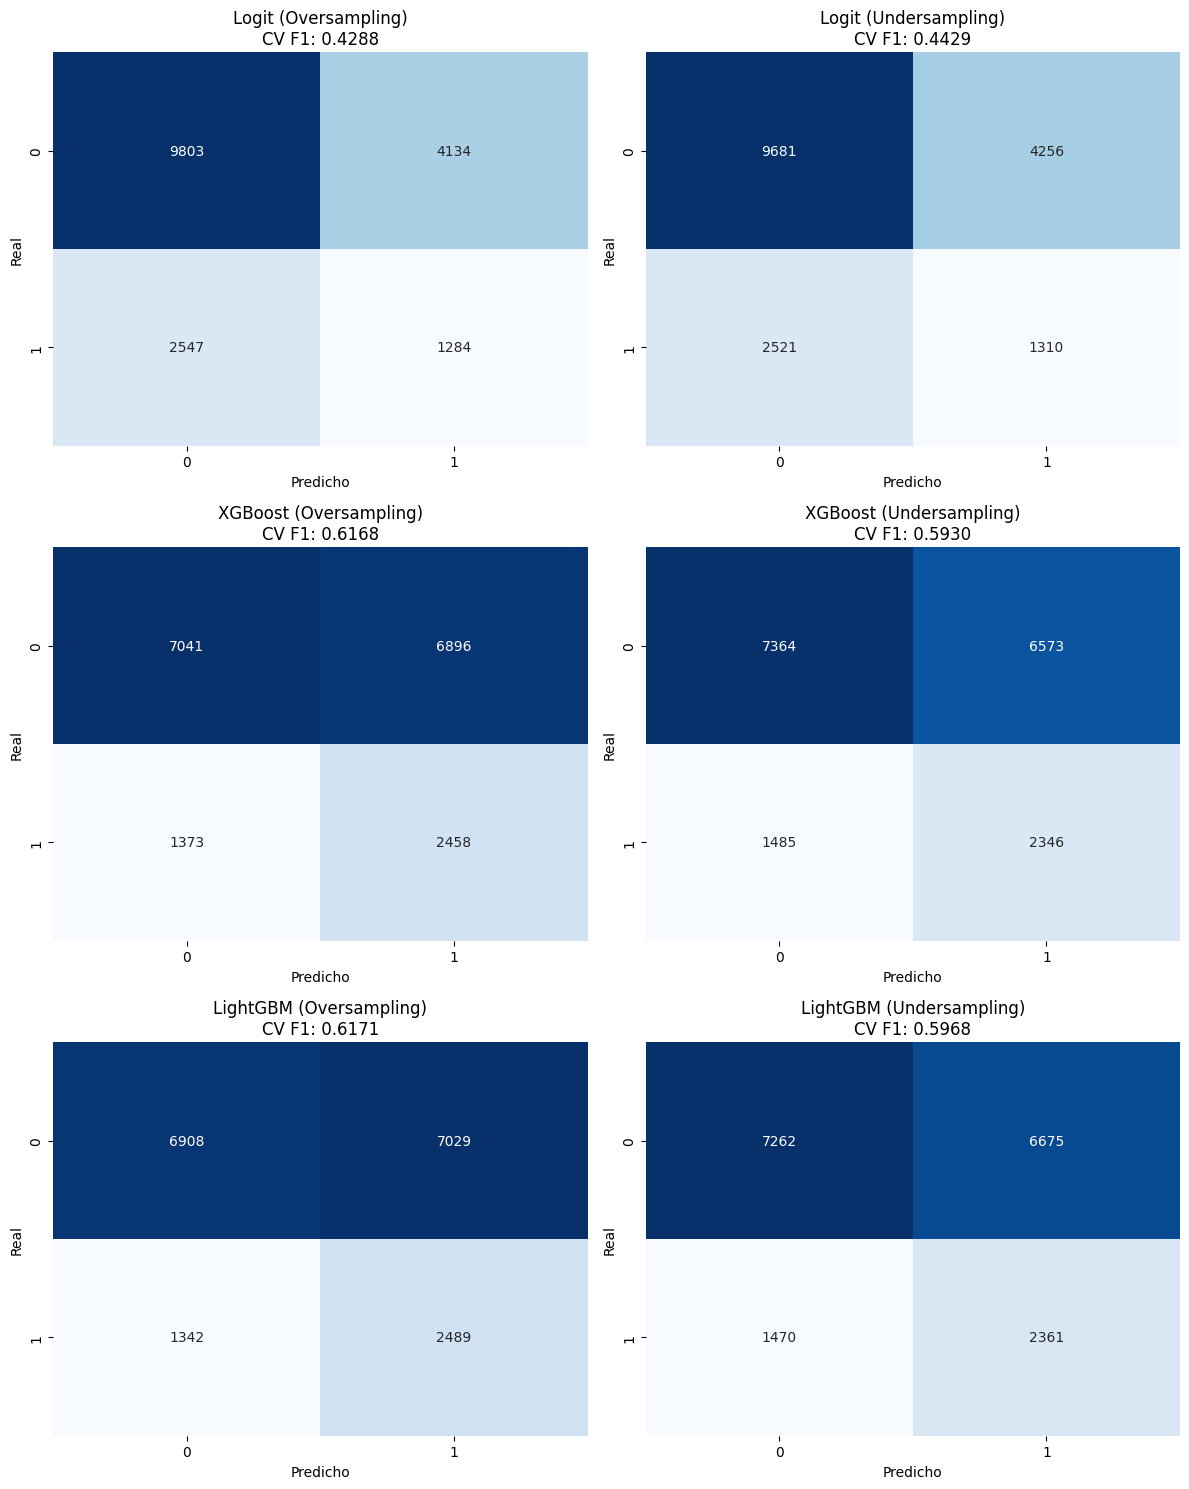

In [5]:

# 1. Definición de Técnicas de Remuestreo
over = SMOTE(random_state=42)
under = RandomUnderSampler(random_state=42)

estrategias = {
    'Oversampling': over.fit_resample(X_train, y_train),
    'Undersampling': under.fit_resample(X_train, y_train)
}

modelos = {
    'Logit': LogisticRegression(max_iter=1000, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

# Configuración de Validación Cruzada (5 Folds)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Bucle de Entrenamiento, Validación y Matriz de Confusión
fig, axes = plt.subplots(3, 2, figsize=(12, 15))
axes = axes.flatten()
idx = 0

for mod_nombre, model in modelos.items():
    for est_nombre, (X_res, y_res) in estrategias.items():
        
        # Validación Cruzada sobre el set de entrenamiento remuestreado
        cv_scores = cross_val_score(model, X_res, y_res, cv=skf, scoring='f1')
        
        # Entrenamiento final para evaluar en Test
        model.fit(X_res, y_res)
        y_pred = model.predict(X_test)
        
        # Matriz de Confusión
        cm = confusion_matrix(y_test, y_pred)
        
        # Graficar Matriz
        sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx], cmap='Blues', cbar=False)
        axes[idx].set_title(f'{mod_nombre} ({est_nombre})\nCV F1: {cv_scores.mean():.4f}')
        axes[idx].set_xlabel('Predicho')
        axes[idx].set_ylabel('Real')
        
        print(f"--- {mod_nombre} con {est_nombre} ---")
        print(f"F1-Score CV (Mean): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
        print(classification_report(y_test, y_pred))
        print("-" * 30)
        
        idx += 1

plt.tight_layout()
plt.show()

[I 2026-05-05 00:17:55,024] A new study created in memory with name: no-name-ef254b20-33bc-4e4a-a08f-77d6e4e35d1c
[I 2026-05-05 00:17:55,437] Trial 0 finished with value: 0.3694197307298638 and parameters: {'learning_rate': 0.021509427037492153, 'num_leaves': 2259, 'max_depth': 7, 'feature_fraction': 0.6364134623615719, 'bagging_fraction': 0.5614492712951923, 'bagging_freq': 4, 'min_child_samples': 113}. Best is trial 0 with value: 0.3694197307298638.
[I 2026-05-05 00:17:55,978] Trial 1 finished with value: 0.3682265041289815 and parameters: {'learning_rate': 0.014733175770448602, 'num_leaves': 4908, 'max_depth': 7, 'feature_fraction': 0.8340944889236824, 'bagging_fraction': 0.7132170624919923, 'bagging_freq': 5, 'min_child_samples': 67}. Best is trial 0 with value: 0.3694197307298638.
[I 2026-05-05 00:17:56,400] Trial 2 finished with value: 0.3687865782286383 and parameters: {'learning_rate': 0.01108867894706369, 'num_leaves': 3913, 'max_depth': 5, 'feature_fraction': 0.82936053641270

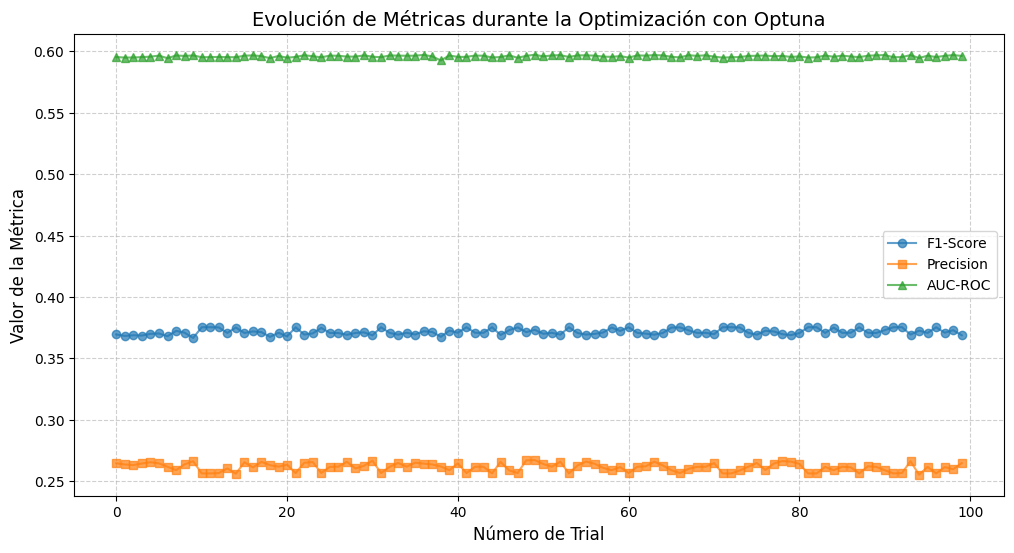

Mejor F1-Score alcanzado: 0.3753
Mejores Hiperparámetros: {'learning_rate': 0.029200550304510783, 'num_leaves': 159, 'max_depth': 10, 'feature_fraction': 0.5011198076225071, 'bagging_fraction': 0.7850694335045658, 'bagging_freq': 1, 'min_child_samples': 150}


In [34]:
import optuna
import lightgbm as lgb
from sklearn.metrics import f1_score, precision_score, roc_auc_score
import matplotlib.pyplot as plt

# 1. Preparar datos con Oversampling para el entrenamiento
X_res, y_res = under.fit_resample(X_train, y_train)

def objective(trial):
    # Definición del espacio de búsqueda de hiperparámetros
    param = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': 42,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.03),
        'num_leaves': trial.suggest_int('num_leaves', 8, 5000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 0.9),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 0.8),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 6),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 150),
    }

    # Entrenamiento del modelo
    gbm = lgb.LGBMClassifier(**param)
    gbm.fit(X_res, y_res)
    
    # Predicción y cálculo de F1-Score
    preds = gbm.predict(X_test)
    f1 = f1_score(y_test, preds)
    
    # Guardar métricas adicionales en los atributos del trial para graficar después
    probs = gbm.predict_proba(X_test)[:, 1]
    trial.set_user_attr('precision', precision_score(y_test, preds))
    trial.set_user_attr('auc', roc_auc_score(y_test, probs))
    
    return f1

# 2. Ejecutar la optimización
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100) # Puedes subir a 100 para mejores resultados

# 3. Extraer métricas de los trials para graficar
trials_df = study.trials_dataframe()
trials_df['f1_score'] = trials_df['value']
trials_df['precision'] = [t.user_attrs['precision'] for t in study.trials]
trials_df['auc'] = [t.user_attrs['auc'] for t in study.trials]

# 4. Visualización de la evolución de las métricas
plt.figure(figsize=(12, 6))
plt.plot(trials_df.index, trials_df['f1_score'], label='F1-Score', marker='o', alpha=0.7)
plt.plot(trials_df.index, trials_df['precision'], label='Precision', marker='s', alpha=0.7)
plt.plot(trials_df.index, trials_df['auc'], label='AUC-ROC', marker='^', alpha=0.7)

plt.title('Evolución de Métricas durante la Optimización con Optuna', fontsize=14)
plt.xlabel('Número de Trial', fontsize=12)
plt.ylabel('Valor de la Métrica', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 5. Mejores resultados
print(f"Mejor F1-Score alcanzado: {study.best_value:.4f}")
print("Mejores Hiperparámetros:", study.best_params)

[I 2026-05-05 02:58:34,922] A new study created in memory with name: no-name-cdb8b6e5-7af8-4338-97ca-f14c2bcc3241


[I 2026-05-05 02:58:56,708] Trial 0 finished with value: 0.3679700887988783 and parameters: {'max_depth': 14, 'min_child_weight': 9, 'gamma': 1.3374764110175668e-06, 'learning_rate': 0.013325947767789384, 'n_estimators': 9067, 'subsample': 0.9277524471958081, 'colsample_bytree': 0.7237591307426031, 'reg_alpha': 6.493912223163302e-07, 'reg_lambda': 3.2647269260015644e-06}. Best is trial 0 with value: 0.3679700887988783.
[I 2026-05-05 02:58:57,049] Trial 1 finished with value: 0.36790697674418604 and parameters: {'max_depth': 7, 'min_child_weight': 5, 'gamma': 0.0005655162496477296, 'learning_rate': 0.0369338033577579, 'n_estimators': 108, 'subsample': 0.7496380662716544, 'colsample_bytree': 0.9714931252729853, 'reg_alpha': 0.0010248158906403797, 'reg_lambda': 0.21554722975094426}. Best is trial 0 with value: 0.3679700887988783.
[I 2026-05-05 02:59:04,110] Trial 2 finished with value: 0.3681521653698027 and parameters: {'max_depth': 3, 'min_child_weight': 10, 'gamma': 0.00867885232627758

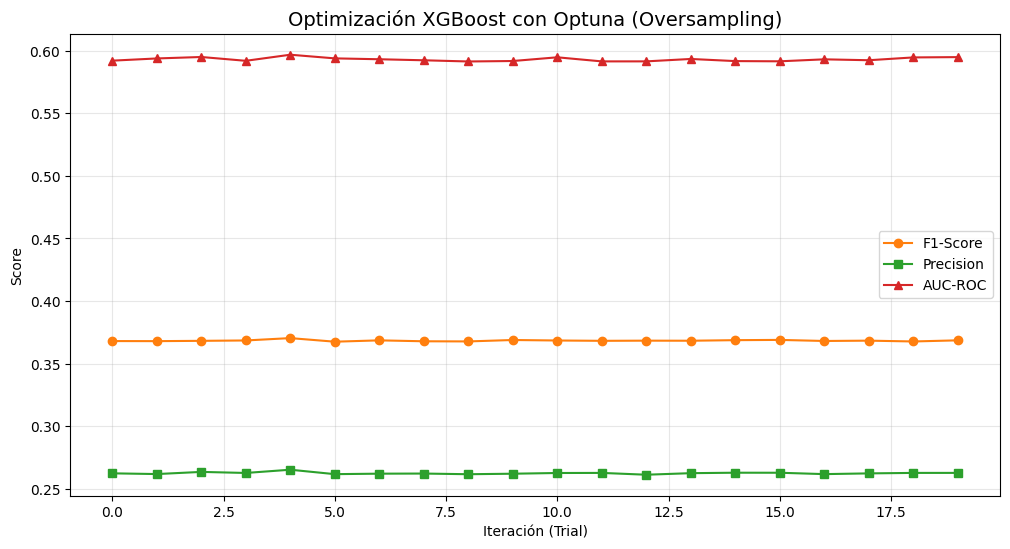

Mejor F1-Score (XGBoost): 0.3703
Parámetros óptimos: {'max_depth': 3, 'min_child_weight': 8, 'gamma': 0.012665424701595762, 'learning_rate': 0.011132053762841699, 'n_estimators': 1907, 'subsample': 0.5406368044475092, 'colsample_bytree': 0.7555724478774137, 'reg_alpha': 4.935855308958136e-08, 'reg_lambda': 0.031985984846583555}


In [8]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, roc_auc_score
import matplotlib.pyplot as plt

# 1. Preparar datos con Oversampling (SMOTE)
X_res, y_res = under.fit_resample(X_train, y_train)

def objective(trial):
    # Espacio de búsqueda basado en los parámetros clave de XGBoost
    param = {
        'verbosity': 0,
        'objective': 'binary:logistic',
        'random_state': 42,
        'eval_metric': 'logloss',
        
        # 1. Control de estructura del árbol
        'max_depth': trial.suggest_int('max_depth', 3, 14),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True), # Controla la poda
        
        # 2. Boosting y Velocidad (Step size shrinkage)
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05),
        'n_estimators': trial.suggest_int('n_estimators', 100, 10000),
        
        # 3. Muestreo (Robustez ante ruido)
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        
        # 4. Regularización (Evitar sobreajuste)
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),  # L1
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True)  # L2
    }

    # Entrenamiento del modelo
    xgb_model = XGBClassifier(**param)
    xgb_model.fit(X_res, y_res)
    
    # Evaluación sobre el set de TEST original
    preds = xgb_model.predict(X_test)
    probs = xgb_model.predict_proba(X_test)[:, 1]
    
    f1 = f1_score(y_test, preds)
    
    # Guardar métricas adicionales para los gráficos
    trial.set_user_attr('precision', precision_score(y_test, preds))
    trial.set_user_attr('auc', roc_auc_score(y_test, probs))
    
    return f1

# 2. Ejecutar la optimización
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective, n_trials=20)

# 3. Extracción de datos y Gráficos
trials_df = study_xgb.trials_dataframe()
trials_df['f1_score'] = trials_df['value']
trials_df['precision'] = [t.user_attrs['precision'] for t in study_xgb.trials]
trials_df['auc'] = [t.user_attrs['auc'] for t in study_xgb.trials]

plt.figure(figsize=(12, 6))
plt.plot(trials_df.index, trials_df['f1_score'], label='F1-Score', marker='o', color='tab:orange')
plt.plot(trials_df.index, trials_df['precision'], label='Precision', marker='s', color='tab:green')
plt.plot(trials_df.index, trials_df['auc'], label='AUC-ROC', marker='^', color='tab:red')

plt.title('Optimización XGBoost con Optuna (Oversampling)', fontsize=14)
plt.xlabel('Iteración (Trial)')
plt.ylabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Mejor F1-Score (XGBoost): {study_xgb.best_value:.4f}")

print("Parámetros óptimos:", study_xgb.best_params)

In [9]:
# Cálculo sugerido basado en tus datos de entrenamiento originales
conteo_clases = y_train.value_counts()
ratio_penalizacion = conteo_clases[0] / conteo_clases[1]

print(f"Ratio de penalización sugerido: {ratio_penalizacion:.2f}")

Ratio de penalización sugerido: 3.64


In [10]:
def objective(trial):
    param = {
        'verbosity': 0,
        'objective': 'binary:logistic',
        'random_state': 42,
        'eval_metric': 'logloss',
        
        # --- PARÁMETRO DE PENALIZACIÓN ---
        # Optuna buscará si penalizar un poco menos o un poco más que el ratio teórico
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, ratio_penalizacion * 1.5),
        
        'max_depth': trial.suggest_int('max_depth', 3, 14),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05),
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000), # Bajé el tope para agilizar trials
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True)
    }

    xgb_model = XGBClassifier(**param)
    xgb_model.fit(X_res, y_res)
    
    preds = xgb_model.predict(X_test)
    probs = xgb_model.predict_proba(X_test)[:, 1]
    
    f1 = f1_score(y_test, preds)
    
    trial.set_user_attr('precision', precision_score(y_test, preds))
    trial.set_user_attr('auc', roc_auc_score(y_test, probs))
    
    return f1

[I 2026-05-05 03:09:59,524] A new study created in memory with name: no-name-3bfe5a35-ceda-473b-a39a-1c24e9b26162
[I 2026-05-05 03:10:02,891] Trial 0 finished with value: 0.3612328471872979 and parameters: {'scale_pos_weight': 2.491531544295027, 'max_depth': 6, 'min_child_weight': 3, 'gamma': 0.030776416078226815, 'learning_rate': 0.03694752842103143, 'n_estimators': 2042, 'subsample': 0.8015732200181308, 'colsample_bytree': 0.7701845348095508, 'reg_alpha': 2.1225220270121845e-06, 'reg_lambda': 0.03934704733515922}. Best is trial 0 with value: 0.3612328471872979.
[I 2026-05-05 03:10:09,189] Trial 1 finished with value: 0.3586479988686183 and parameters: {'scale_pos_weight': 3.6876290228075437, 'max_depth': 9, 'min_child_weight': 4, 'gamma': 0.00019117251632692932, 'learning_rate': 0.03279327261836117, 'n_estimators': 2767, 'subsample': 0.7744361832912465, 'colsample_bytree': 0.8130530007891416, 'reg_alpha': 0.0007879786146450254, 'reg_lambda': 0.013576891562045813}. Best is trial 0 wit

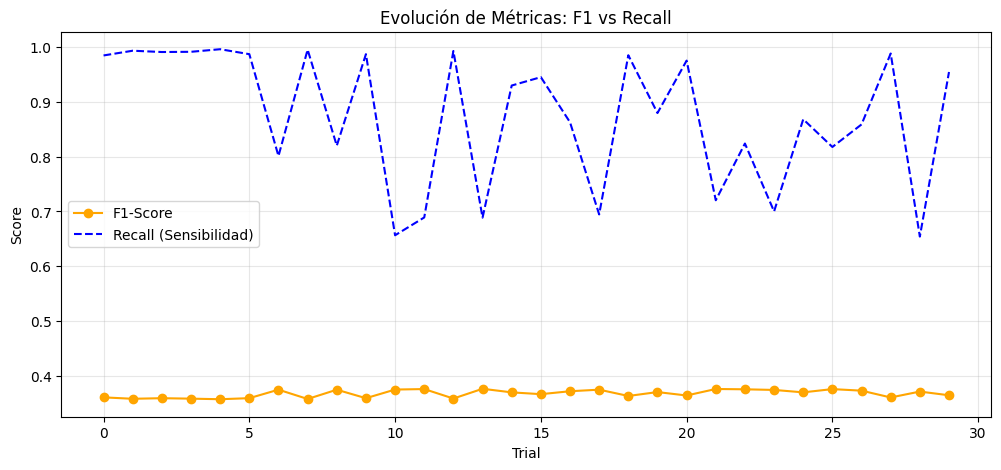


--- MEJOR MODELO ENCONTRADO ---
Mejor F1-Score: 0.3769
Matriz de Confusión Final:


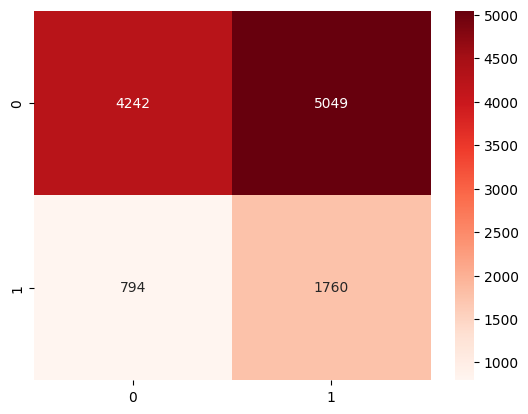

In [ ]:
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from imblearn.under_sampling import RandomUnderSampler

X_encoded = pd.get_dummies(df[['EDAD_EN_DIAS', 'ETNIA', 'DIAGNOSTICO', 'CANTIDAD', 'ALTITUD_MSNM']], 
                           columns=['ETNIA', 'DIAGNOSTICO'], 
                           drop_first=True)
y = df['TARGET_PRIORIDAD']

# 2. SPLIT CON DATOS YA CODIFICADOS
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, 
                                                    random_state=42, stratify=y)

# 3. UNDERSAMPLING
under = RandomUnderSampler(random_state=42)
X_res, y_res = under.fit_resample(X_train, y_train)

# 4. RATIO PARA PENALIZACIÓN
counts = y_train.value_counts()
ratio_teorico = counts[0] / counts[1]

# 4. OPTIMIZACIÓN CON OPTUNA
def objective(trial):
    param = {
        'verbosity': 0,
        'objective': 'binary:logistic',
        'random_state': 42,
        'eval_metric': 'logloss',
        
        # Penalización personalizada para priorizar Clase 1 (Anemia)
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, ratio_teorico * 1.2),
        
        # Hiperparámetros basados en documentación técnica
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05),
        'n_estimators': trial.suggest_int('n_estimators', 100, 4096),
        
        
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True)
    }

    model = XGBClassifier(**param)
    model.fit(X_res, y_res)
    
    preds = model.predict(X_test)
    f1 = f1_score(y_test, preds)
    
    # Guardamos métricas auxiliares
    trial.set_user_attr('precision', precision_score(y_test, preds))
    trial.set_user_attr('recall', recall_score(y_test, preds))
    trial.set_user_attr('auc', roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))
    
    return f1

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

# 5. VISUALIZACIÓN DE RESULTADOS
trials_df = study.trials_dataframe()
plt.figure(figsize=(12, 5))
plt.plot(trials_df.index, trials_df['value'], label='F1-Score', color='orange', marker='o')
plt.plot(trials_df.index, [t.user_attrs['recall'] for t in study.trials], label='Recall (Sensibilidad)', color='blue', linestyle='--')
plt.title('Evolución de Métricas: F1 vs Recall')
plt.xlabel('Trial')
plt.ylabel('Score')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 6. EVALUACIÓN DEL MEJOR MODELO
best_model = XGBClassifier(**study.best_params)
best_model.fit(X_res, y_res)
y_pred_final = best_model.predict(X_test)

print(f"\n--- MEJOR MODELO ENCONTRADO ---")
print(f"Mejor F1-Score: {study.best_value:.4f}")
print("Matriz de Confusión Final:")
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Reds')
plt.show()